## Function Approximation Using Least Squares and Neural Networks

This notebook follows the coursework workflow:    
1.Load and explore the dataset  
2.Prepare training and validation data  
3.Fit a 4th-order polynomial least-squares baseline  
4.Train a feedforward neural network for regression  
5.Evaluate both models on the validation set  
6.Compare optimisation behaviour and generalisation

本 notebook 按照 coursework brief 的推荐流程完成两个模型：  
一个是四次多项式 least squares baseline，  
另一个是前馈神经网络回归模型，  
并比较它们的 optimisation behaviour、overfitting 和 generalisation。

If libraries are not installed correctly  
try %pip install numpy pandas matplotlib in a new code cell

          x          y
0  1.095824   1.635425
1 -0.244486  -0.338836
2  1.434392   3.926012
3  0.789472  -0.027757
4 -1.623291  11.301925
          x          y
0 -0.792290   0.380422
1  1.673768   6.860788
2  1.125176   1.614931
3 -1.557646   9.929234
4  1.988139  14.135489


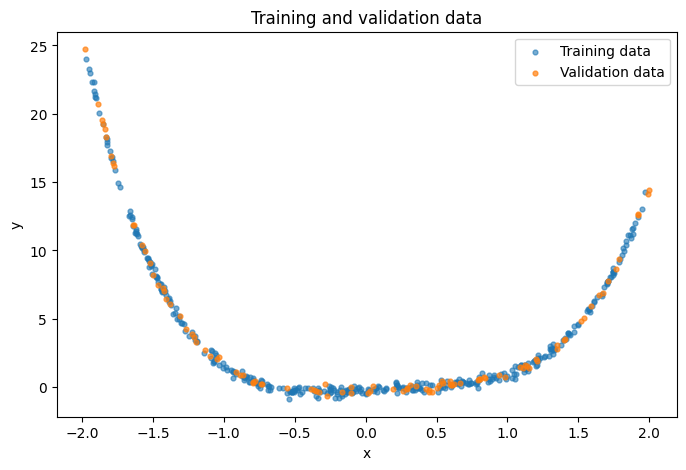

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 读取训练集和验证集
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("val.csv")

# 提取输入 x 和目标 y
x_train = train_df[["x"]].values
y_train = train_df["y"].values

x_val = val_df[["x"]].values
y_val = val_df["y"].values

# 看一下数据前几行
print(train_df.head())
print(val_df.head())

# 画出训练集和验证集散点图
plt.figure(figsize = (8, 5))
plt.scatter(x_train, y_train, label = "Training data", s = 12, alpha=0.6)
plt.scatter(x_val, y_val, label = "Validation data", s = 12, alpha=0.7)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Training and validation data")
plt.legend()
plt.show()

#### Results and discussion
- The scatter plot suggests that the relationship between (x) and (y) is nonlinear, so a simple linear model would not be sufficient.  
- The points follow a smooth overall trend but do not lie exactly on a single curve, which indicates that noise is present in the observations.  
- The training and validation sets also appear to have a similar pattern, which suggests that they are sampled from the same underlying function.


## Step 2: Prepare training and validation data  

#### Purpose  
The purpose of this step is to prepare the data for model fitting while keeping the validation set independent for evaluation and model selection.

#### Methodology  
- The training set is used to fit model parameters, while the validation set is reserved for evaluation and generalisation analysis.  
- For the neural network, the input variable is standardised using the mean and standard deviation of the training set. The same transformation is then applied to the validation input. The target variable is kept on its original scale so that predictions and MSE values remain directly interpretable. 
- The same transformation is then applied to the validation set. This avoids data leakage and improves the stability of gradient-based optimisation.

#### Core
- After standardisation, the neural network is trained in a more numerically stable space, where the variables have comparable scales.  
- This is useful because gradient-based optimisation can be sensitive to the scale of inputs and targets.  
- Importantly, the validation set is not used to estimate the scaling statistics, so it remains independent from training.



In [194]:
x_mean = x_train.mean(axis = 0) # computes the mean of training inputs.
x_std = x_train.std(axis = 0) #computes the standard deviation of training inputs.
y_mean = y_train.mean(axis = 0) #computes the mean of training targets.
y_std = y_train.std(axis = 0) #computes the standard deviation of training targets.

x_train_scaled = (x_train - x_mean) / x_std #standardises training inputs.
x_val_scaled = (x_val - x_mean) / x_std #standardises validation inputs using training statistics.


	•	在 Step 1 的数据探索中，y 的数值范围是比较正常、可解释的
	•	没有出现特别极端的尺度问题
	•	因此为了让预测结果、误差和拟合图保持在原始尺度上更容易解释
	•	本文选择只对输入 x 做标准化，而保留 y 的原始尺度


## Step 3: Least Squares 4th-order polynomial baseline  

#### Purpose
The purpose of this step is to build the classical baseline required by the coursework, so that it can later be compared with the neural network approach.

#### Methodology 
Transform the input $x$ into a feature matrix $X$ containing $[1, x, x^2, x^3, x^4]$. The parameters are solved analytically using the Normal Equation (via np.linalg.lstsq), which minimizes the Mean Squared Error (MSE).

In [195]:
def build_polynomial_features(x, degree = 4):
    feature_list = [] #creates an empty list to store each feature column.
    for power in range(degree + 1): #loops from power 0 to 4.
        feature_list.append(x ** power) #appends x^0, x^1, x^2, x^3, x^4.
    return np.hstack(feature_list) #stacks those columns into one feature matrix.

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

x_train_poly = build_polynomial_features(x_train, degree=4)
x_val_poly = build_polynomial_features(x_val, degree=4)

poly_coefficients, residuals, rank, singular_values = np.linalg.lstsq(
    x_train_poly,
    y_train,
    rcond = None
)

poly_train_pred = x_train_poly @ poly_coefficients
poly_val_pred = x_val_poly @ poly_coefficients

poly_train_mse = mse(y_train, poly_train_pred)
poly_val_mse = mse(y_val, poly_val_pred)

print("Polynomial coefficients:")
print(poly_coefficients)

print("Polynomial training MSE:", poly_train_mse)
print("Polynomial validation MSE:", poly_val_mse)

Polynomial coefficients:
[-0.21463817  0.50759346  0.28989804 -0.80366203  1.20539343]
Polynomial training MSE: 0.0422503850793052
Polynomial validation MSE: 0.0307308080692366


/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_30045/1671599411.py:19: RuntimeWarning: divide by zero encountered in matmul
  poly_train_pred = x_train_poly @ poly_coefficients
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_30045/1671599411.py:19: RuntimeWarning: overflow encountered in matmul
  poly_train_pred = x_train_poly @ poly_coefficients
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_30045/1671599411.py:19: RuntimeWarning: invalid value encountered in matmul
  poly_train_pred = x_train_poly @ poly_coefficients


/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_30045/3404518166.py:8: RuntimeWarning: divide by zero encountered in matmul
  y_grid_poly = x_grid_poly @ poly_coefficients
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_30045/3404518166.py:8: RuntimeWarning: overflow encountered in matmul
  y_grid_poly = x_grid_poly @ poly_coefficients
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_30045/3404518166.py:8: RuntimeWarning: invalid value encountered in matmul
  y_grid_poly = x_grid_poly @ poly_coefficients


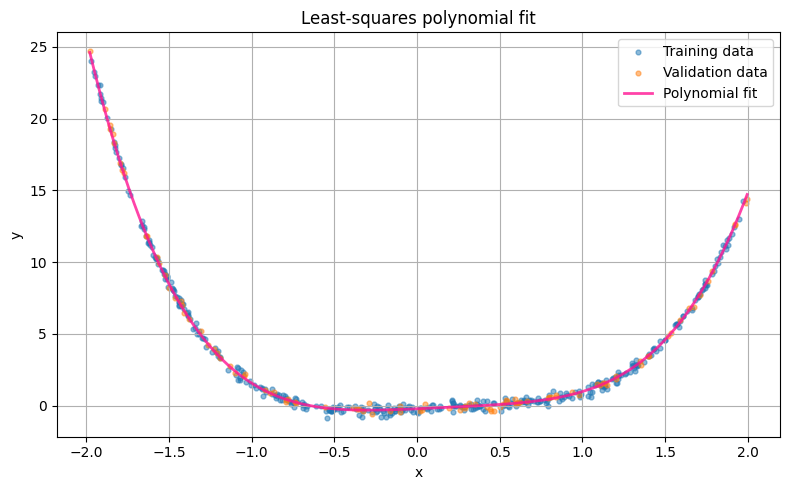

In [196]:
x_grid = np.linspace(
    min(x_train.min(), x_val.min()),
    max(x_train.max(), x_val.max()),
    400
).reshape(-1, 1)

x_grid_poly = build_polynomial_features(x_grid, degree=4)
y_grid_poly = x_grid_poly @ poly_coefficients

plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, s = 12, alpha = 0.5, label="Training data")
plt.scatter(x_val, y_val, s = 12, alpha = 0.5, label="Validation data")
plt.plot(x_grid, y_grid_poly, linewidth = 2, alpha = 0.8, color = "deeppink", label="Polynomial fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Least-squares polynomial fit")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

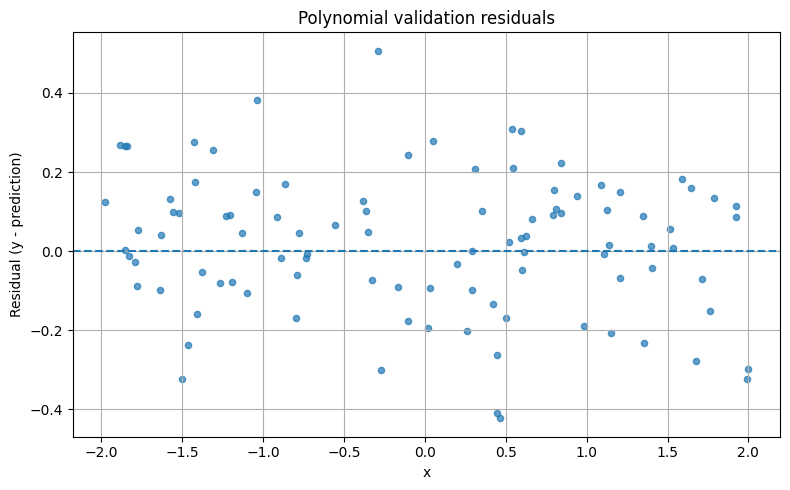

In [197]:
poly_val_residuals = y_val - poly_val_pred

plt.figure(figsize = (8, 5))
plt.scatter(x_val, poly_val_residuals, s=20, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("x")
plt.ylabel("Residual (y - prediction)")
plt.title("Polynomial validation residuals")
plt.grid(True)
plt.tight_layout()
plt.show()

## Step 4: Neural Network Regression

#### Purpose  
To implement a flexible, non-linear neural network for regression and train it to approximate the unknown function.

#### Methodology 


In [198]:
%pip install numpy pandas matplotlib scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

def build_model(random_state = 42):
    return MLPRegressor(
        hidden_layer_sizes = (64, 32),
        activation = 'relu',
        solver = 'adam',
        alpha = 1e-4,
        learning_rate_init = 0.005,
        max_iter = 2000,
        early_stopping = True,
        validation_fraction = 0.2,
        n_iter_no_change = 50,
        random_state = random_state
    )

scaler_nn = StandardScaler()
x_train_nn_scaled = scaler_nn.fit_transform(x_train)
x_val_nn_scaled = scaler_nn.transform(x_val)

model_nn = build_model(random_state=42)
model_nn.fit(x_train_nn_scaled, y_train)

y_train_pred_nn = model_nn.predict(x_train_nn_scaled)
y_val_pred_nn = model_nn.predict(x_val_nn_scaled)

nn_train_mse = mean_squared_error(y_train, y_train_pred_nn)
nn_val_mse = mean_squared_error(y_val, y_val_pred_nn)

print("Neural Network training MSE:", nn_train_mse)
print("Neural Network validation MSE:", nn_val_mse)
print("Number of iterations used:", model_nn.n_iter_)



Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.
Neural Network training MSE: 0.05491393698009009
Neural Network validation MSE: 0.06379908689042196
Number of iterations used: 210


/Users/keyi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/keyi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/keyi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/keyi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/keyi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/keyi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/keyi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWar

## Step 5: Evaluate model performance



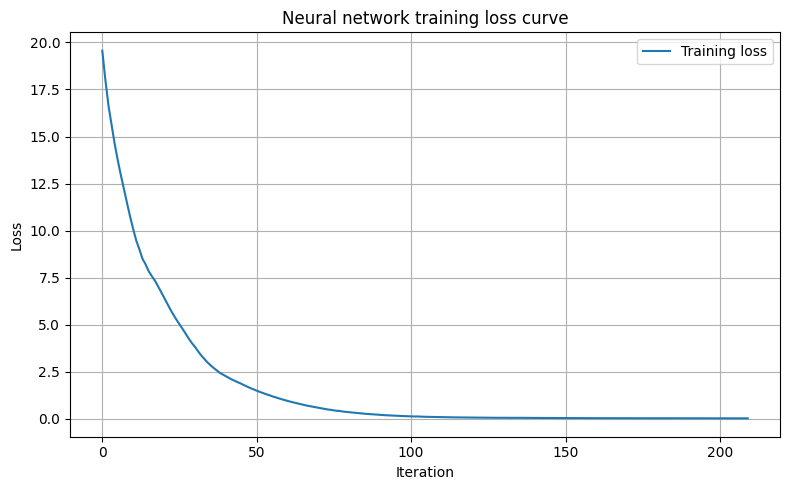

In [199]:
plt.figure(figsize=(8, 5))
plt.plot(model_nn.loss_curve_, label="Training loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Neural network training loss curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

/Users/keyi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/keyi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/keyi/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


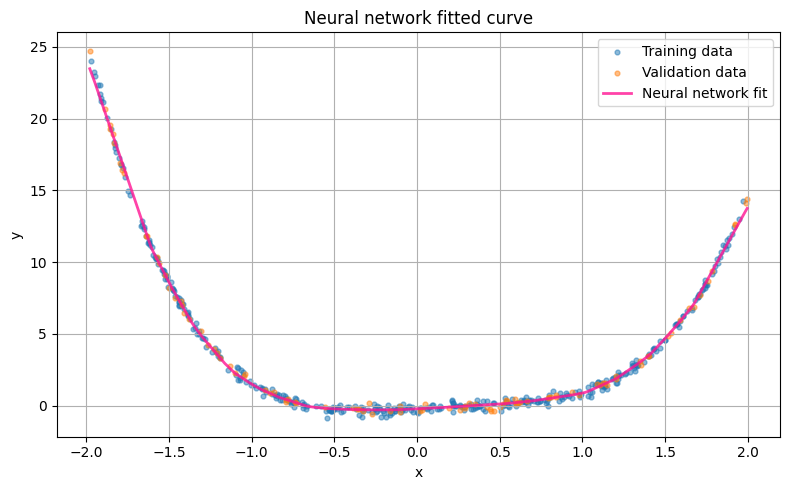

In [200]:
x_grid_nn_scaled = scaler_nn.transform(x_grid)
y_grid_nn = model_nn.predict(x_grid_nn_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, s = 12, alpha = 0.5, label = "Training data")
plt.scatter(x_val, y_val, s = 12, alpha = 0.5, label = "Validation data")
plt.plot(x_grid, y_grid_nn, linewidth = 2, alpha = 0.8, color = "deeppink", label = "Neural network fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Neural network fitted curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Step 6: Analyse and compare the approaches


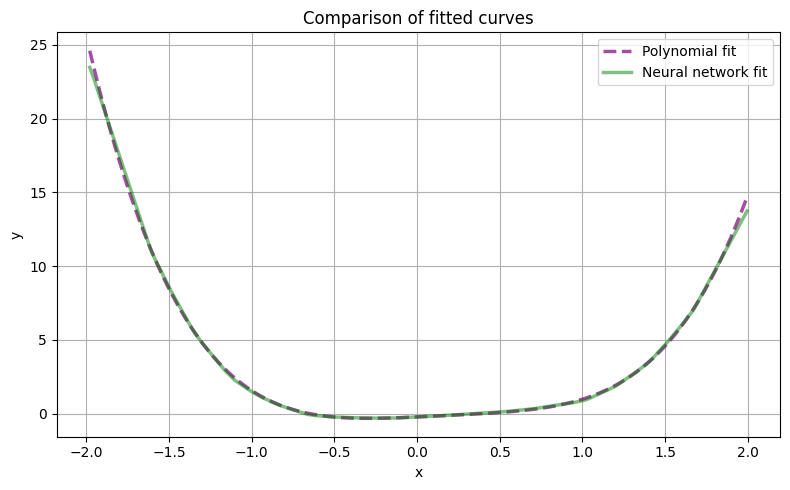

                      Model  Training MSE  Validation MSE  Generalisation Gap
0  Least Squares Polynomial      0.042250        0.030731           -0.011520
1            Neural Network      0.054914        0.063799            0.008885


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(x_grid, y_grid_poly, linewidth = 2.5, alpha = 0.7, linestyle="--", label = "Polynomial fit")
plt.plot(x_grid, y_grid_nn, linewidth = 2.5, alpha = 0.5, label = "Neural network fit")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Comparison of fitted curves")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

comparison_df = pd.DataFrame({
    "Model": ["Least Squares Polynomial", "Neural Network"],
    "Training MSE": [float(poly_train_mse), float(nn_train_mse)],
    "Validation MSE": [float(poly_val_mse), float(nn_val_mse)],
    "Generalisation Gap": [
        float(poly_val_mse - poly_train_mse),
        float(nn_val_mse - nn_train_mse)
    ]
})

print(comparison_df)